In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import math
import matplotlib.cm as cm
import random
import scipy.signal as sp
import seaborn as sns
from IPython.display import display
from scipy.stats import kruskal

### Combine

In [22]:
Data=r"F:\data\Code\final\ecg 60s 10min\features"
files_in_directory = os.listdir(Data)
print(files_in_directory)

['combined_data.csv', 'ECG100.csv', 'ECG110.csv', 'ECG118.csv', 'ECG121.csv', 'ECG122.csv', 'ECG123.csv', 'ECG124.csv', 'ECG125.csv', 'ECG75.csv', 'ECG76.csv', 'ECG81.csv', 'ECG83.csv', 'ECG84.csv', 'ECG85.csv', 'ECG86.csv', 'ECG88.csv', 'ECG89.csv', 'ECG90.csv', 'ECG91.csv', 'ECG93.csv', 'ECG94.csv', 'ECG95.csv', 'ECG96.csv', 'train.csv', 'valid.csv']


In [23]:
all_files = []
for filename in files_in_directory:
    if filename.endswith('.csv'):
        filepath = os.path.join(Data, filename)
        df = pd.read_csv(filepath)
        all_files.append(df)

combined_df = pd.concat(all_files, ignore_index=True)
print("Combined DataFrame created with shape:", combined_df.shape)

Combined DataFrame created with shape: (189591, 31)


In [24]:
output_filepath = os.path.join(Data, 'combined_data.csv')
combined_df.to_csv(output_filepath, index=False)
print(f"Combined data saved to: {output_filepath}")

Combined data saved to: F:\data\Code\final\ecg 60s 10min\features\combined_data.csv


In [25]:
ECG=pd.read_csv(r"F:\data\Code\final\ecg 60s 10min\features\combined_data.csv")

In [26]:
Label_counts = ECG['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

,Label,Count
0,normal,108328
1,preictal,9575
2,postictal,7653
3,ictal,3003


### Ranges

In [14]:
def Analysis_Feature(df, label_col='label', exclude_cols=None):
    import pandas as pd

    if label_col not in df.columns:
        raise ValueError(f"'{label_col}' not found in DataFrame")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = ['subject', 'run', 'sfreq', 'start_time', 'end_time']
    if exclude_cols:
        exclude.extend(exclude_cols)

    features = [col for col in numeric_cols if col not in exclude]
    print(f"Analyzing {len(features)} numeric features: {features}\n")

    for feature in features:
        ranges_list = []

        for label in df[label_col].unique():
            values = df[df[label_col] == label][feature].dropna()
            if len(values) == 0:
                continue
            stats = {
                'Label': label,
                'Min': values.min(),
                'Max': values.max(),
                'Mean': values.mean(),
                'Std': values.std(),
                'Median': values.median(),
                '25th_percentile': values.quantile(0.25),
                '75th_percentile': values.quantile(0.75)
            }
            ranges_list.append(stats)

        df_feature = pd.DataFrame(ranges_list)

        df_feature = df_feature.sort_values(by='Mean', ascending=False).reset_index(drop=True)

        print(f"==== Feature: {feature} ====")
        display(df_feature)

In [15]:
def Full_Analysis(df, label_col='label', exclude_cols=None):

    if label_col not in df.columns:
        raise ValueError(f"'{label_col}' not found in DataFrame")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    exclude = ['subject', 'run', 'encoded_label', 'sfreq',
               'start_time', 'end_time']

    if exclude_cols:
        exclude.extend(exclude_cols)

    features = [col for col in numeric_cols if col not in exclude]

    results = []

    for feature in features:
        groups = [
            df[df[label_col] == lbl][feature].dropna()
            for lbl in df[label_col].unique()
        ]

        if all(len(g) > 0 for g in groups):
            stat, p = kruskal(*groups)
            results.append({
                'Feature': feature,
                'H-stat': stat,
                'p-value': p
            })
        else:
            results.append({
                'Feature': feature,
                'H-stat': np.nan,
                'p-value': np.nan
            })

    df_stats = pd.DataFrame(results).sort_values('p-value')

    return df_stats

### VIsualize Analysis

In [9]:
def Plot_Boxplots(df, label_col='label'):
    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.boxplot(x=label_col, y=feat, data=df, ax=axs[i])
        axs[i].set_title(f'{feat}', fontsize=11)
        axs[i].set_xlabel('')
        axs[i].set_ylabel(feat)

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Boxplots of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [10]:
def Plot_Violin(df, label_col='label', bins=30):

    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.violinplot(x=label_col, y=feat, data=df, ax=axs[i], inner='quartile')
        axs[i].set_title(f'Violin of {feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Count')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Violines of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [11]:
def Plot_Distribution(df, label_col='label'):
    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.kdeplot(data=df, x=feat, hue=label_col, fill=True, ax=axs[i])
        axs[i].set_title(f'{feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Density')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Distributions of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [12]:
def Plot_Histograms(df, label_col='label', bins=30):

    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.histplot(data=df, x=feat, hue=label_col, kde=False, bins=bins, ax=axs[i], alpha=0.7)
        axs[i].set_title(f'Histogram of {feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Count')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Histograms of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [13]:
def Plot_Correlation(df):

    num_cols = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Features")
    plt.tight_layout()
    plt.show()

### Analysis

#### Visualize

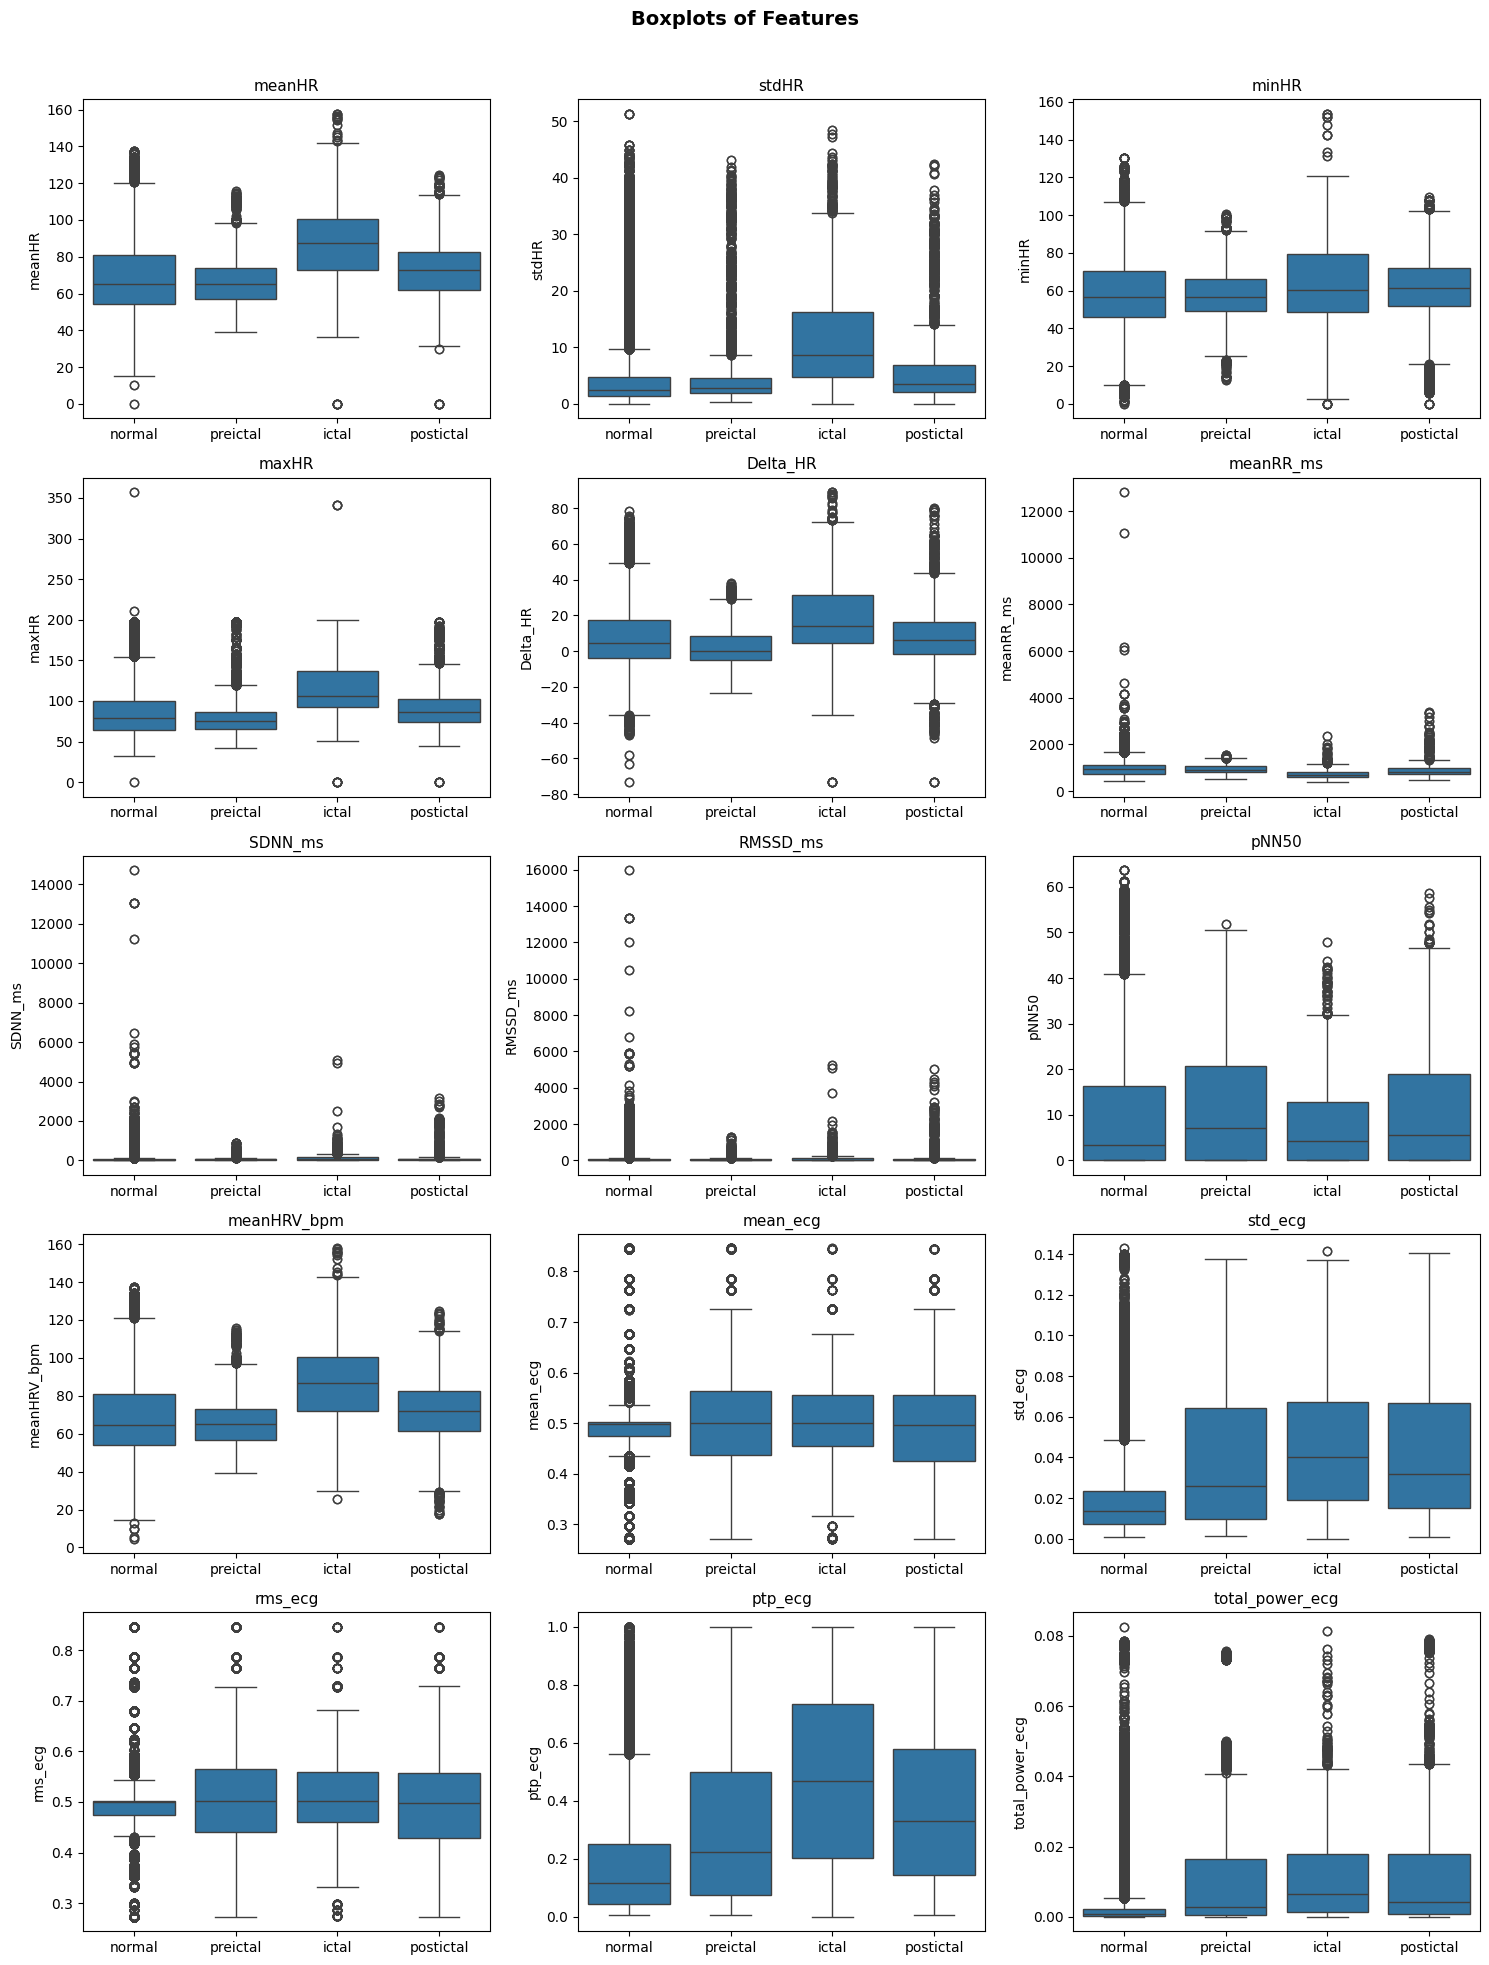

In [14]:
Plot_Boxplots(ECG)

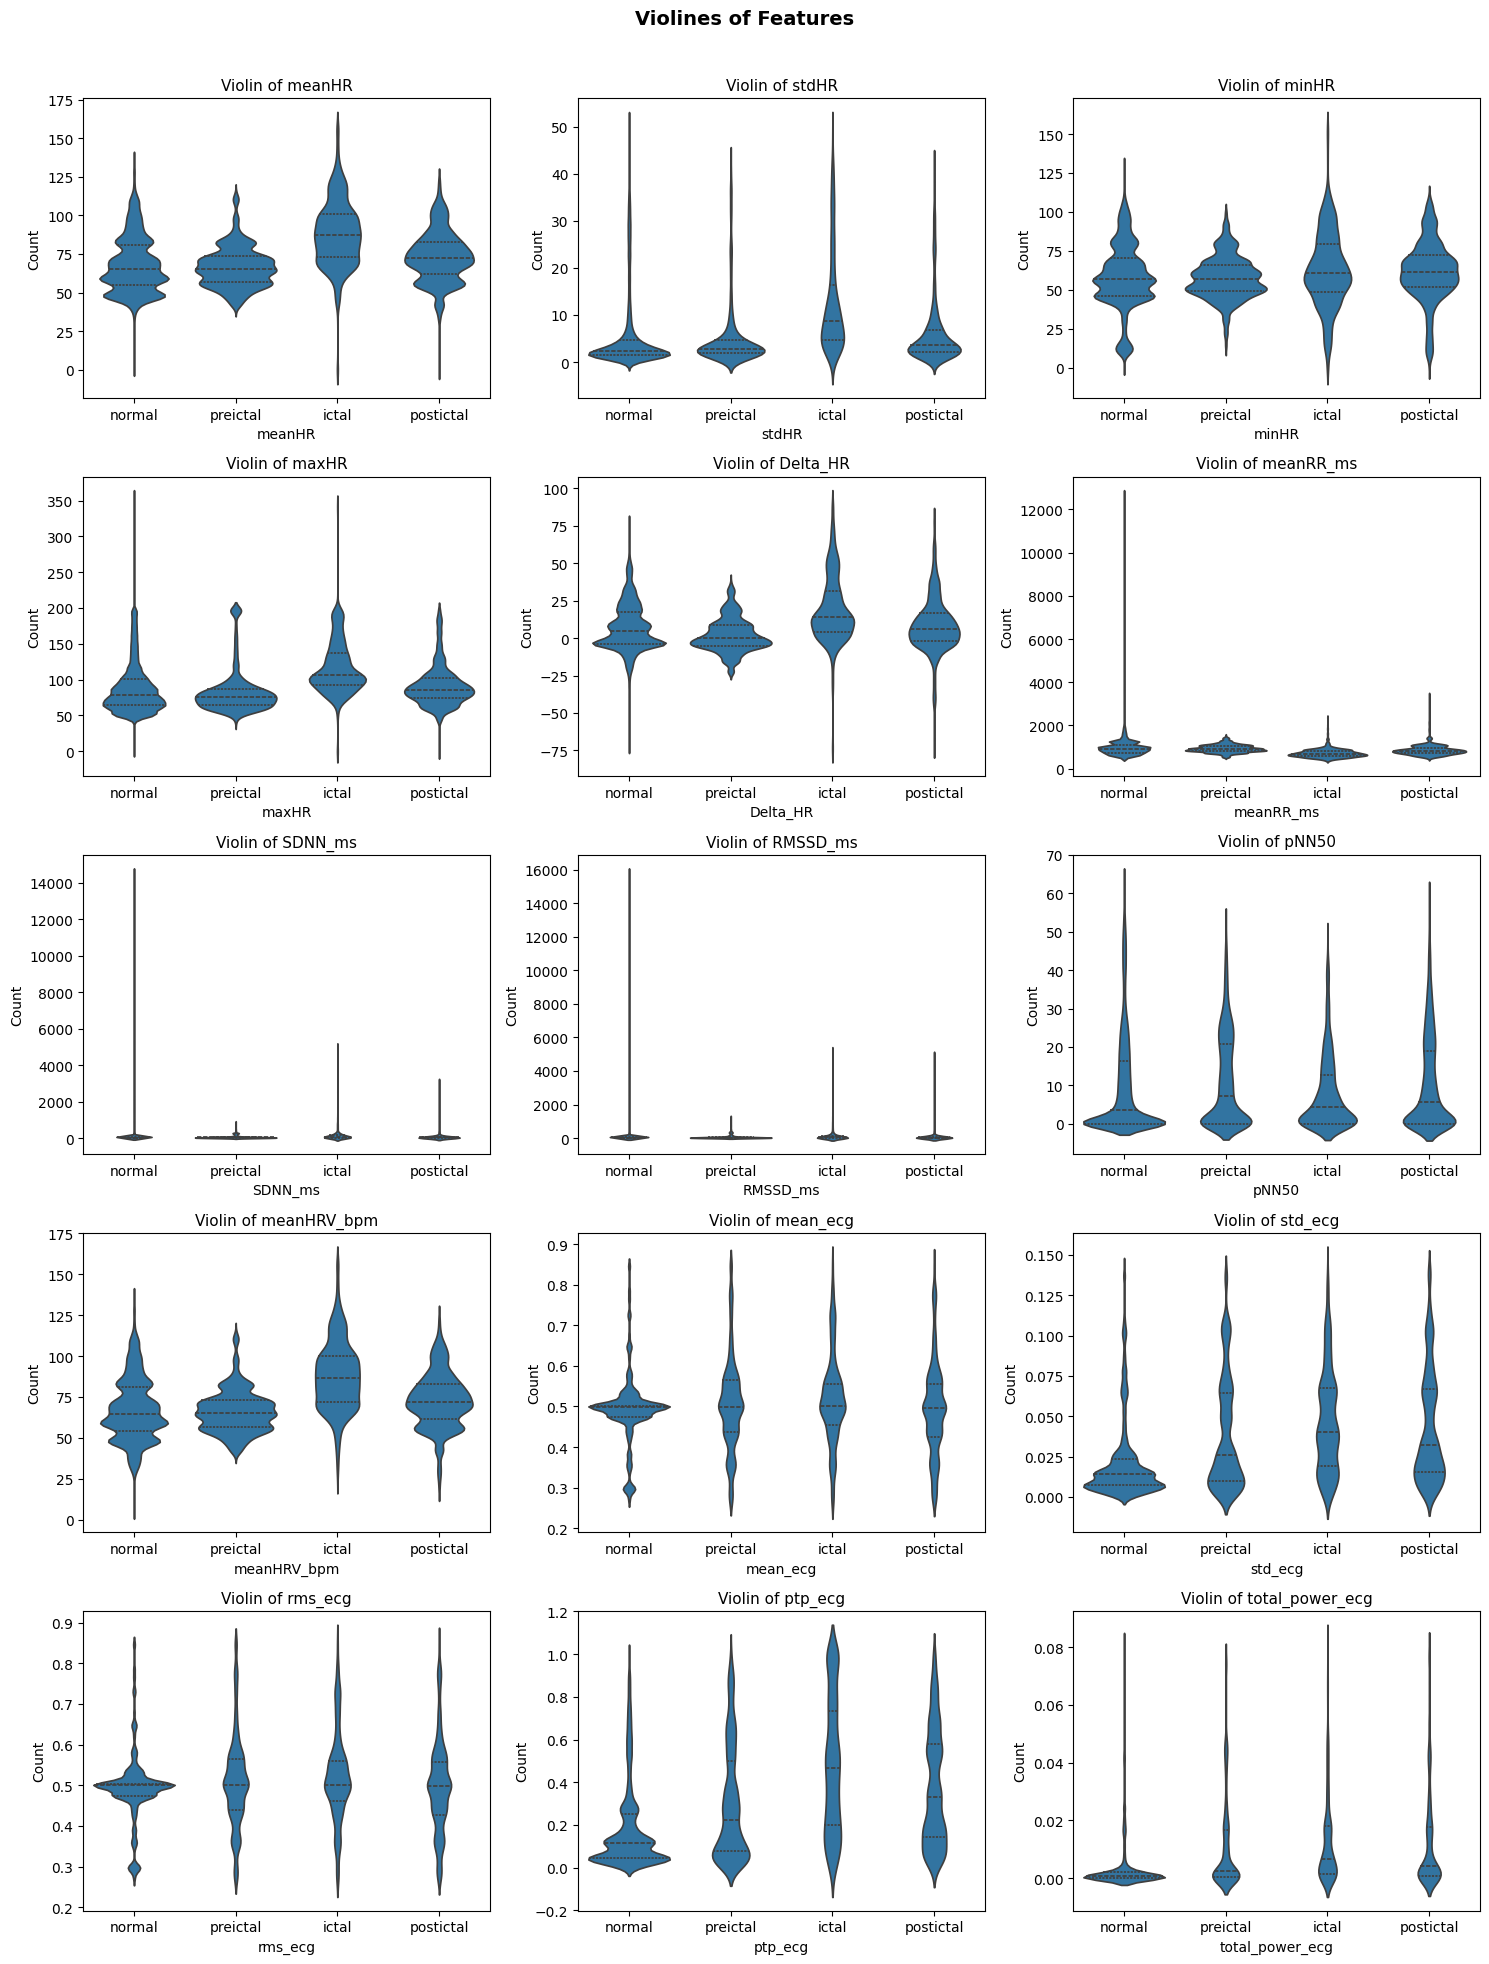

In [15]:
Plot_Violin(ECG)

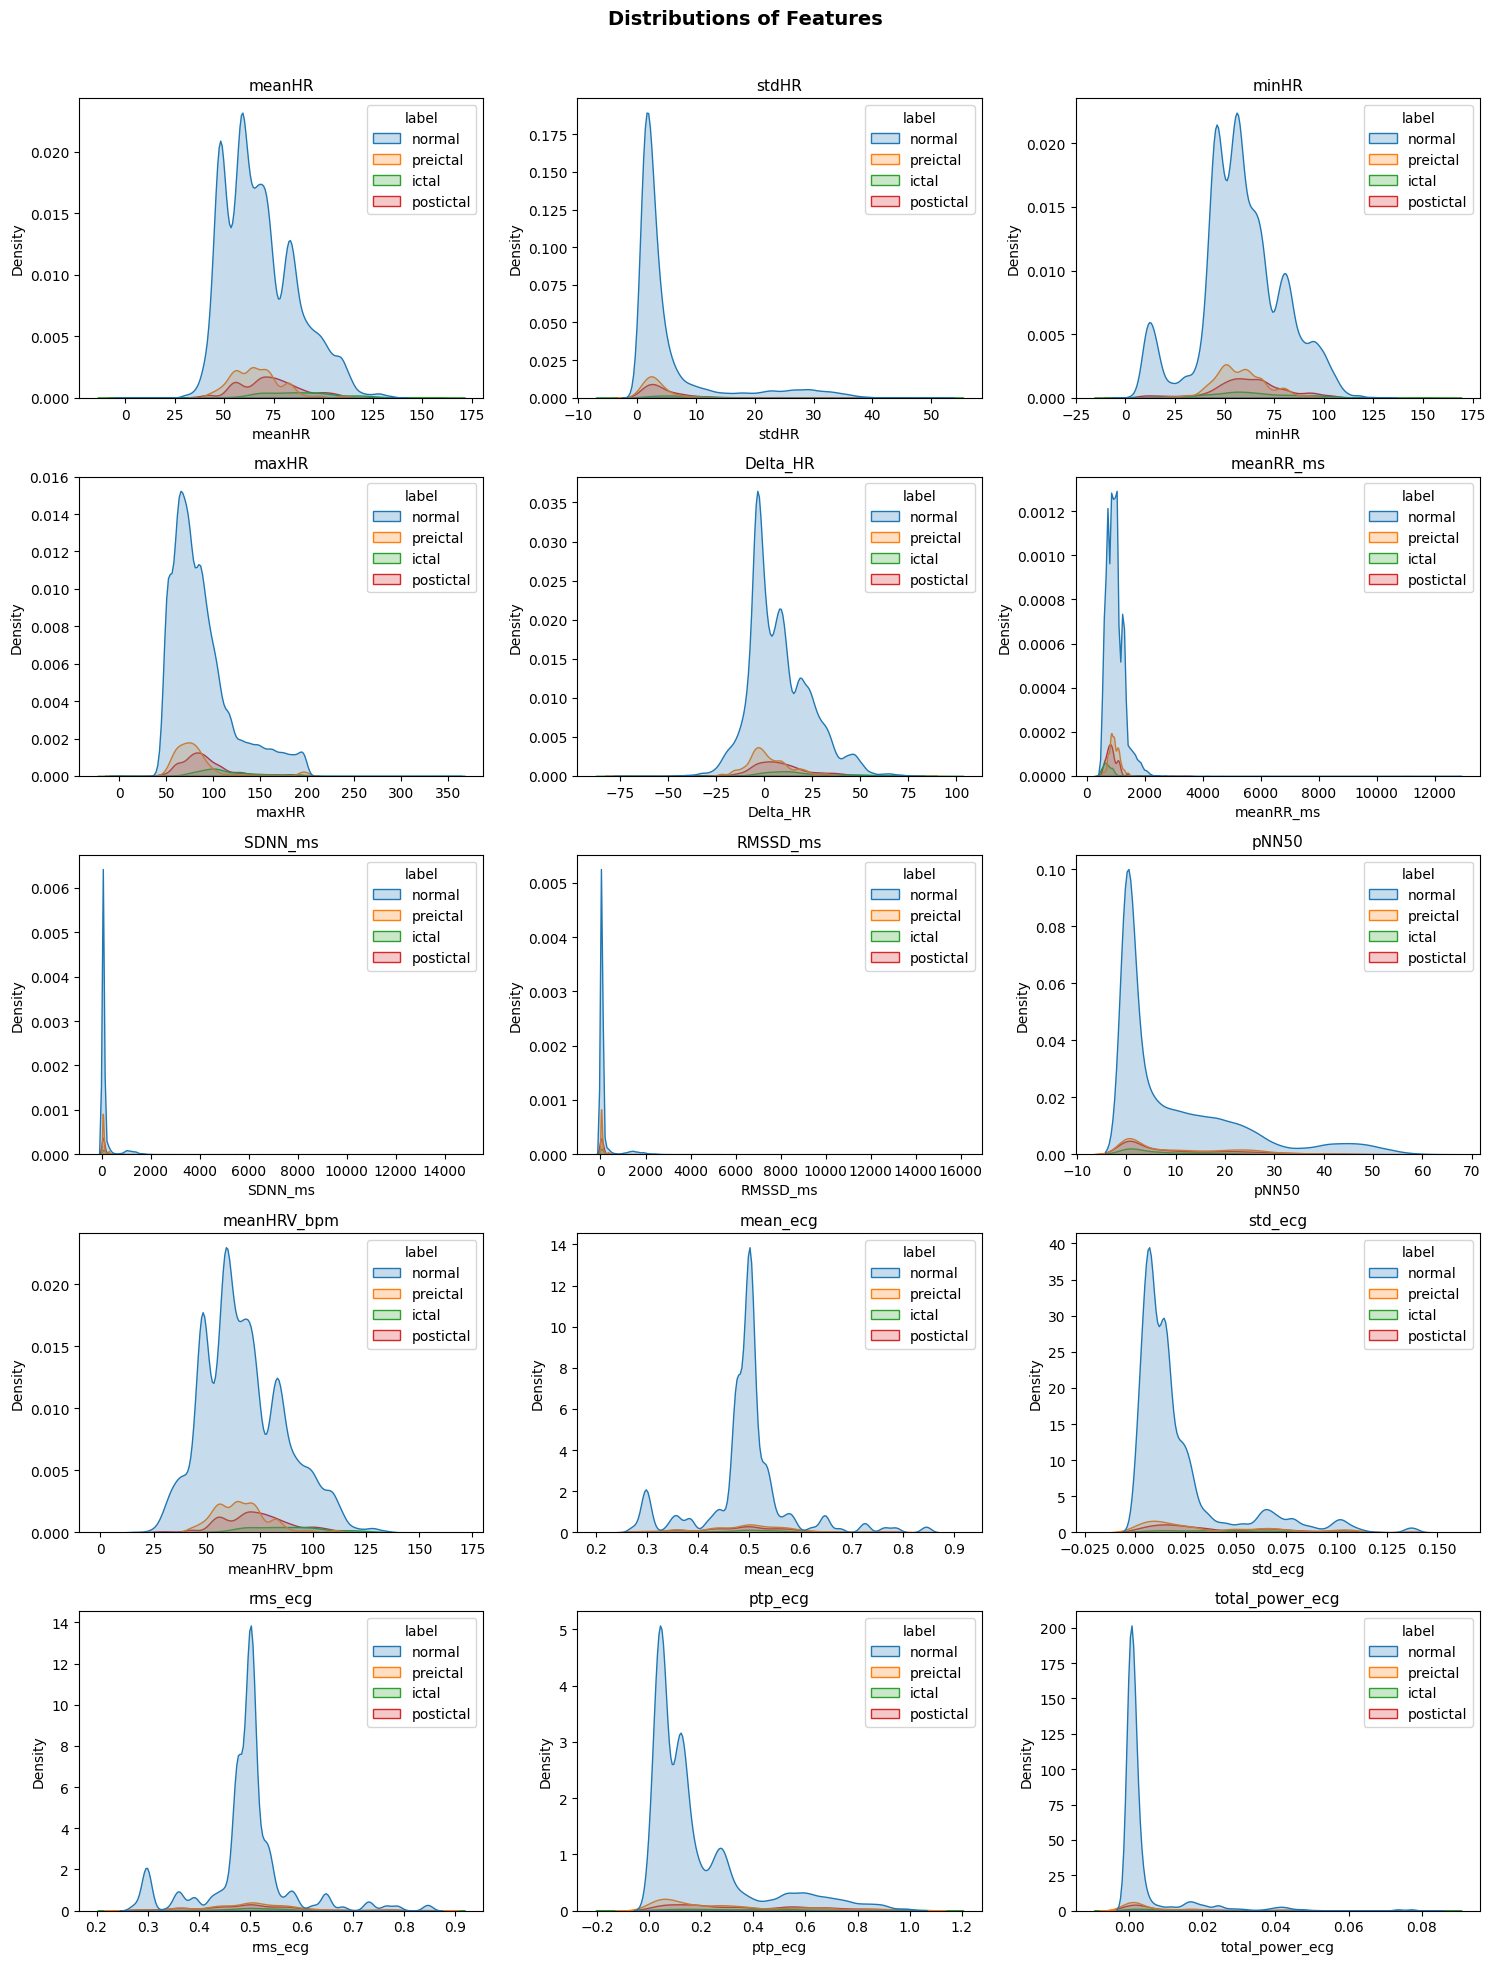

In [16]:
Plot_Distribution(ECG)

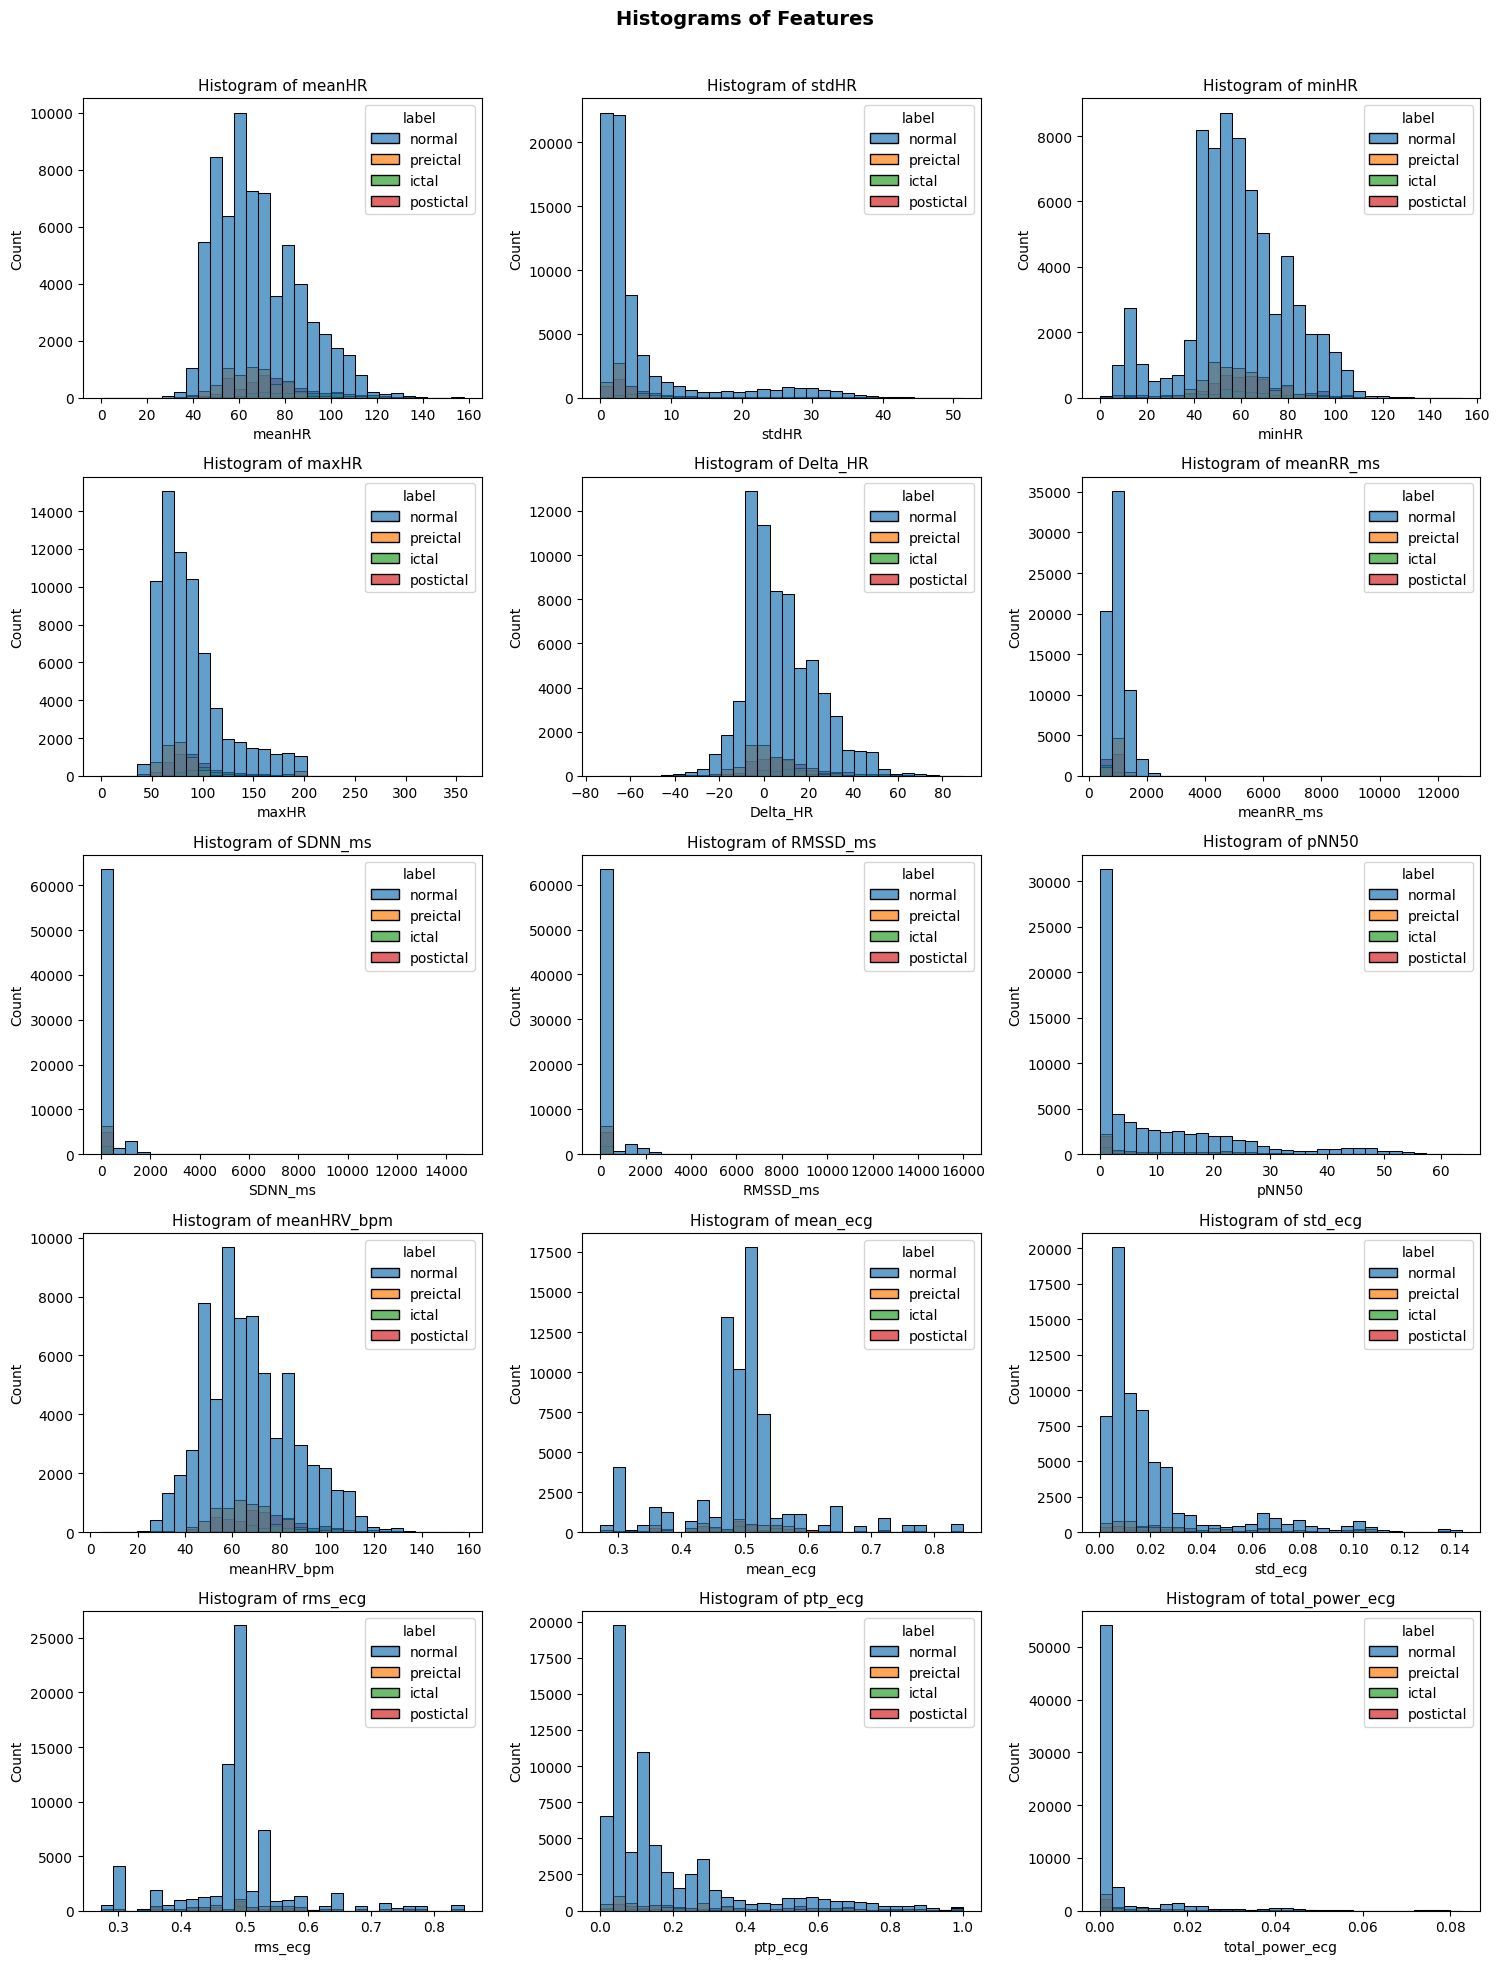

In [17]:
Plot_Histograms(ECG)

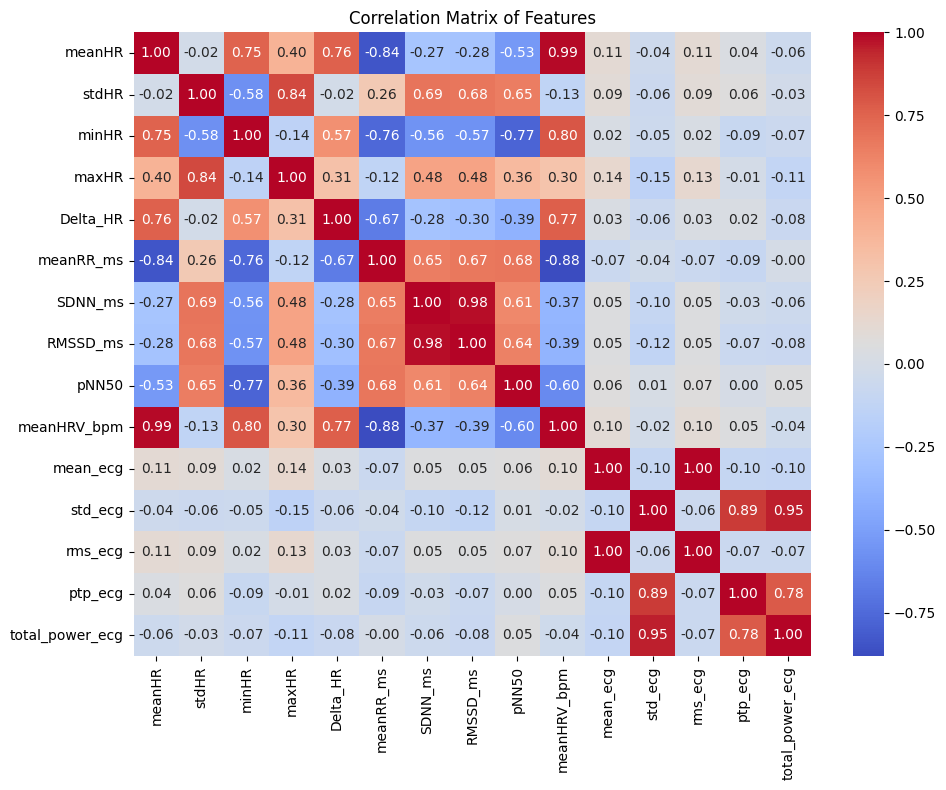

In [18]:
Plot_Correlation(ECG)

#### Numerical

In [3]:
ECG=pd.read_csv(r"F:\graduation project\data\Code\final\ecg 60s 10min\features\combined_data.csv")

In [4]:
def convert(df, label_col='label'):

    df = df.copy()
    df.loc[df[label_col] == 'postictal', label_col] = 'normal'
    return df

In [5]:
ECG=convert(ECG)

In [6]:
import pandas as pd

ECG = ECG[ECG['status'] == 'success'].copy()

print(ECG['status'].value_counts())


status
success    128532
Name: count, dtype: int64


In [7]:
Label_counts = ECG['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

,Label,Count
0,normal,115966
1,preictal,9575
2,ictal,2991


In [16]:
Analysis_Feature(ECG)

Analyzing 18 numeric features: ['meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms', 'RMSSD_ms', 'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg', 'bp_0_5_3_ecg', 'n_beats', 'encoded_label']

==== Feature: meanHR ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,ictal,36.135897,157.671817,88.805148,20.606677,87.316266,72.818369,100.812829
1,normal,10.394373,137.298475,68.415891,18.189574,65.536295,54.565284,81.080540
2,preictal,39.167316,115.581437,66.425679,12.996314,65.149577,56.963568,73.340490


==== Feature: stdHR ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,ictal,0.632968,48.427319,12.616392,10.720618,8.755527,4.865839,16.456610
1,normal,0.260338,51.329862,5.782327,8.187686,2.483651,1.489149,4.939515
2,preictal,0.301975,43.134744,5.224453,7.142563,2.811929,1.917307,4.605539


==== Feature: minHR ====


...

,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,ictal,9.013184e-08,0.013102,0.001169,0.001803,0.000580,0.000131,0.001405
1,preictal,7.928181e-07,0.012879,0.001137,0.002153,0.000198,0.000024,0.001041
2,normal,2.630665e-07,0.014375,0.000490,0.001500,0.000048,0.000012,0.000140


==== Feature: n_beats ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,ictal,5.0,156.0,87.089268,21.102958,86.0,71.0,100.0
1,normal,5.0,137.0,67.074013,19.099629,65.0,54.0,80.0
2,preictal,39.0,115.0,65.650339,12.740821,65.0,56.0,72.0


==== Feature: encoded_label ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,preictal,2.0,2.0,2.0,0.0,2.0,2.0,2.0
1,normal,1.0,1.0,1.0,0.0,1.0,1.0,1.0
2,ictal,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
Full_Analysis(ECG)

,Feature,H-stat,p-value
0,meanHR,2728.180158,0.000000e+00
1,stdHR,3144.577384,0.000000e+00
3,maxHR,2738.617971,0.000000e+00
4,Delta_HR,2221.364248,0.000000e+00
5,meanRR_ms,2609.299810,0.000000e+00
14,total_power_ecg,4001.994106,0.000000e+00
11,std_ecg,3995.171573,0.000000e+00
9,meanHRV_bpm,2609.299810,0.000000e+00
15,bp_0_5_3_ecg,4458.706288,0.000000e+00
13,ptp_ecg,3864.588768,0.000000e+00
